# Recipe from your fridge — Project in Database Management Systems
- Kota OKUDA
- Ryunosuke TANAKA

The link for:
- [slides](https://docs.google.com/presentation/d/1R9rgm_toUiJmP9IsRJyBhouK0CMylBNIUpmdK5mXWHo/edit?slide=id.g3d88ceff4b2_0_140#slide=id.g3d88ceff4b2_0_140)
- [Github Repository](https://github.com/KotaOK-00/Database-Management-Systems-2026)

---
**Absract**

In this project, we develop a database which suggests dishes you can cook from the ingredients in your fridge. We first consider a basic database which can search missing ingredients to cook a specific dish, or which can search available dishes given user's fridge. As an extension, we added some features: substitution of missing ingredients, filtering based on genre or difficulty, ingredients in staple (always available ingredients), and recipe creation via large language models from the current ingredients.


---
Inside Out

One might think:
> When I get home and look into my fridge, I find there are lots of ingredients but I don’t know how to cook them...

this is the original motivation of this project. Our database deals with this problem by showcasing

1. Which ingredients you need to cook the dish (Section 2.1.);
2. What you can possibly cook with the ingredients you have (Section 2.2. partial match);
3. What you can definitely cook only with the ingredients you have (Section 2.3. complete match).

---
Inside Out 2

After starting using this database, a user might think:
> * Every time I use, I have to put all the ingredients like salt, sugar, oil, etc.
> * I only have shallots right now but the recipe says I need onions. I think I can substitute shallots with onions...
> * Just out of my curiosity, I queried italian dishes with tomatoes but it returns 300,000 hits...

To cope with this, we implemented:

* Staple Logic: common pantry staples, such as "salt" or "oil," can be registered as `staple` to avoid manual entering into the my_fridge list for every query (Section 3.1.);

* Substitution Logic: The system automatically recognises "shallots" as a valid substitute when "onions" are missing from the inventory (Section 3.2.);

* Filtering Logic: the results can be narrowed down using some attributes (metadata), such as by genre or difficulty level (Section 3.3.);




In [ ]:
!pip install anthropic -q #for scenario 4
print("anthropic SDK installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 635.9/635.9 kB 6.4 MB/s eta 0:00:00
anthropic SDK installed.


---
## Section 1: ER Modeling and Relational Schema

### 1.1 Entities

Two kinds of objects need to be managed:

Table 1: Dish
- Examples: Gratin, meat sauce pasta, etc.
- Attributes:
  - `dish_id` — unique internal identifier (primary key)
  - `name` — display name of the dish

Table 2: Ingredient
- Examples: carrot, onion, pork, etc.
- Attributes:
  - `ingredient_id` — unique identifier (primary key)
  - `name` — display name of the ingredient

---



### 1.2 Relationship

#### Cardinality

Many-to-many (N:M) relationship
- One dish contains many ingredients (nikujaga contains carrot, onion, pork, potato, …).
- One ingredient is used in many dishes (carrot appears in nikujaga, in curry rice, …).



#### Participation constraints

- Dish side: total participation — a "dish with zero ingredients" has no meaning here, so every Dish must be connected to at least one Ingredient via `contains`.
- Ingredient side: partial participation — an ingredient can exist in the database without being `used_in` any dish yet (e.g., *carrot* has been registered but no recipe uses it).

#### No Weak Entity

- Both Dish and Ingredient are uniquely identified by their own primary keys (`dish_id`, `ingredient_id`) without borrowing another entity's key.

---



### 1.3 ER Diagram (below)


- `□` Entity
- `◇` Relationship
- `=` total participation
- `—○` partial participation

---



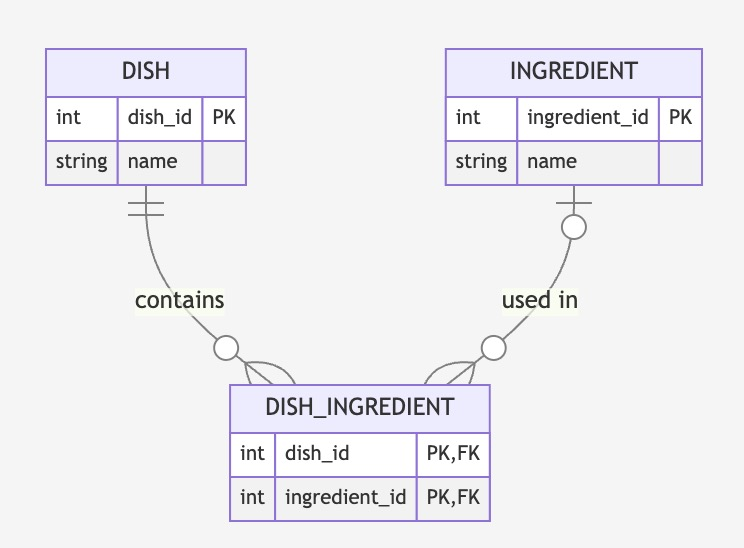

### 1.4 Relational Schema

Applied to our ER model:

| ER element | → | Relation |
|:--|:-:|:--|
| `Dish` entity            | → | `Dish(dish_id, name)` |
| `Ingredient` entity      | → | `Ingredient(ingredient_id, name)` |
| `contains` relationship (N:M) | → | `Dish_Ingredient(dish_id, ingredient_id)` |

The junction table `Dish_Ingredient` carries:

- Composite primary key `(dish_id, ingredient_id)` — no duplicate (dish, ingredient) pairs allowed.
- Foreign key `dish_id` references `Dish.dish_id`.
- Foreign key `ingredient_id` references `Ingredient.ingredient_id`.

---

- referential integrity: a row cannot be inserted into `Dish_Ingredient` whose `dish_id` does not already exist in `Dish`.


---
## Section 2: Database and Queries

With the schema now verified, this section will write the `CREATE TABLE` statements for all three tables, attaching the full set of integrity constraints: `PRIMARY KEY`, `FOREIGN KEY`, `NOT NULL`, `UNIQUE`, and `CHECK`.


In [ ]:
import sqlite3
import pandas as pd

# Connect to the simple database file
conn = sqlite3.connect('fridge_project_simple.db')
cursor = conn.cursor()

cursor.executescript('''
PRAGMA foreign_keys = ON;

DROP TABLE IF EXISTS Dish_Ingredient;
DROP TABLE IF EXISTS Ingredient;
DROP TABLE IF EXISTS Dish;

-- Basic Dish Table
CREATE TABLE Dish (
    dish_id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT NOT NULL UNIQUE
);

-- Basic Ingredient Table
CREATE TABLE Ingredient (
    ingredient_id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT NOT NULL UNIQUE
);

-- Junction Table for N:M Relationship
CREATE TABLE Dish_Ingredient (
    dish_id INTEGER,
    ingredient_id INTEGER,
    PRIMARY KEY (dish_id, ingredient_id),
    FOREIGN KEY (dish_id) REFERENCES Dish(dish_id) ON DELETE CASCADE,
    FOREIGN KEY (ingredient_id) REFERENCES Ingredient(ingredient_id) ON DELETE CASCADE
);

-- Basic Sample Data Insertion
INSERT INTO Ingredient (name) VALUES
('Carrot'), ('Onion'), ('Potato'), ('Pork'),
('Curry Roux'), ('Celery'), ('Minced Beef'), ('Tomato Sauce'),
('Salt'), ('Oil'), ('Shallot'),
('Butter'), ('Milk'), ('Cheese'), ('Flour'),
('Buckwheat Flour'), ('Egg'), ('Ham'), ('Sugar'),
('Mascarpone'), ('Coffee'), ('Cacao Powder'), ('Ladyfingers'),
('Chicken'), ('Rice'), ('Soy Sauce');

INSERT INTO Dish (name) VALUES
('Nikujaga'),
('Curry Rice'),
('Meat Sauce Pasta'),
('Hachis Parmentier'),
('Gratin'),
('Galette'),
('Crepe'),
('Tiramisu'),
('Oyakodon');

-- Mapping ingredients to dishes [cite: 30]

-- 1. Nikujaga: Pork, Potato, Onion, Carrot
INSERT INTO Dish_Ingredient (dish_id, ingredient_id) VALUES (1, 4), (1, 3), (1, 2), (1, 1);

-- 2. Curry: Pork, Potato, Onion, Carrot, Curry Roux
INSERT INTO Dish_Ingredient (dish_id, ingredient_id) VALUES (2, 4), (2, 3), (2, 2), (2, 1), (2, 5);

-- 3. Meat Sauce: Minced Beef, Onion, Tomato Sauce, Celery
INSERT INTO Dish_Ingredient (dish_id, ingredient_id) VALUES (3, 7), (3, 2), (3, 8), (3, 6);

-- 4. Hachis Parmentier: Minced Beef, Potato, Onion, Butter, Milk
INSERT INTO Dish_Ingredient (dish_id, ingredient_id) VALUES (4, 7), (4, 3), (4, 2), (4, 12), (4, 13);

-- 5. Gratin: Potato, Cheese, Milk, Butter
INSERT INTO Dish_Ingredient (dish_id, ingredient_id) VALUES (5, 3), (5, 14), (5, 13), (5, 12);

-- 6. Galette: Buckwheat Flour, Egg, Ham, Cheese
INSERT INTO Dish_Ingredient (dish_id, ingredient_id) VALUES (6, 16), (6, 17), (6, 18), (6, 14);

-- 7. Crepe: Flour, Egg, Milk, Sugar
INSERT INTO Dish_Ingredient (dish_id, ingredient_id) VALUES (7, 15), (7, 17), (7, 13), (7, 19);

-- 8. Tiramisu: Sugar, Mascarpone, Egg, Coffee, Cacao Powder, Ladyfingers
INSERT INTO Dish_Ingredient (dish_id, ingredient_id)
SELECT d.dish_id, i.ingredient_id FROM Dish d, Ingredient i
WHERE d.name = 'Tiramisu' AND i.name IN ('Sugar', 'Mascarpone', 'Egg', 'Coffee', 'Cacao Powder', 'Ladyfingers');

-- 9. Oyakodon: Soy Sauce, Onion, Egg, Chicken, Rice
INSERT INTO Dish_Ingredient (dish_id, ingredient_id)
SELECT d.dish_id, i.ingredient_id FROM Dish d, Ingredient i
WHERE d.name = 'Oyakodon' AND i.name IN ('Soy Sauce', 'Onion', 'Egg', 'Chicken', 'Rice');
''')
conn.commit()

def run_query(sql, params=()):
    return pd.read_sql_query(sql, conn, params=params)

print("Database initialised.")

Database initialised.


### 2.1. Find missing ingredients

* User Situation
  * The user examines their current fridge and selects a specific target dish, such as Hachis Parmentier, to cook. The goal is to generate a "shopping list" by identifying which required ingredients are currently missing from the fridge.

* Logic: Set Difference
  * Let $R$ be the set of ingredients required for the dish;
  * $A$ be the set of ingredients available in the fridge.
  * The set of missing ingredients $M$ is defined as

$$
M = R \setminus A = \{ i \mid i \in R \land i \notin A \}
$$

In SQL, this logic is implemented using a `LEFT JOIN` between the recipe requirements and the available inventory, filtering for records where no match is found (`IS NULL`).

In [ ]:
# Query: Find missing ingredients for 'target dish'
# User has ingredients in `my_fridge`
target_dish = 'Hachis Parmentier'
my_fridge = ('Minced Beef', 'Pork', 'Potato')

q_missing = f'''
SELECT
    i.name AS Missing_Ingredient
FROM Dish d
JOIN Dish_Ingredient di ON d.dish_id = di.dish_id
JOIN Ingredient i ON di.ingredient_id = i.ingredient_id
LEFT JOIN (
    SELECT ingredient_id
    FROM Ingredient
    WHERE name IN {my_fridge}
) AS Owned ON i.ingredient_id = Owned.ingredient_id
WHERE d.name = ? AND Owned.ingredient_id IS NULL;
'''

print(f"Missing ingredients for {target_dish}:")
run_query(q_missing, params=(target_dish,))

Missing ingredients for Hachis Parmentier:


,Missing_Ingredient
0,Onion
1,Butter
2,Milk


### 2.2. Partial Match of ingredients to dishes

* User Situation
  * The user has specific ingredients (e.g., Carrot, Celery) and wants to find all dishes in the database that use at least one of these items
  * `OR` search

* Logic
  * Let $R$ be the set of ingredients required for the dish;
  * $A$ be the set of ingredients available in the fridge.
  * The dish $d$ is selected if

$$R_d \cap A \neq \emptyset$$

In SQL, this is implemented by joining the `Dish`, `Ingredient`, and `Dish_Ingredient` tables. The `WHERE ... IN` acts as a `OR` filter. The `DISTINCT` keyword is necessary because a dish containing both ingredients would otherwise appear multiple times in the result set.

N.B. If $R_d \cup A$, this returns the large list which contains all the required ingredients and the ingredients in the fridge.

In [ ]:
# Query: Find dishes that contain at least one of the given ingredients
# User has: 'Carrot', 'Celery'
my_ingredients = ('Carrot', 'Celery')

q_partial_match = f'''
SELECT DISTINCT
    d.name AS Dish_Name
FROM Dish d
JOIN Dish_Ingredient di ON d.dish_id = di.dish_id
JOIN Ingredient i ON di.ingredient_id = i.ingredient_id
WHERE i.name IN {my_ingredients};
'''

print(f"Dishes you can make (at least partially) with {my_ingredients}:")
run_query(q_partial_match)

Dishes you can make (at least partially) with ('Carrot', 'Celery'):


,Dish_Name
0,Curry Rice
1,Meat Sauce Pasta
2,Nikujaga


### 2.3. Complete Match of ingredients to dishes


* User Situation
  * The user has a set of ingredients and wants to find dishes that can be prepared immediately without purchasing any additional items.
  * `AND` search
  
  
* Logic
  * set of required ingredients for a dish ($R_d$)
  * a subset of the available ingredients ($A$)
  * A dish $d$ is selected if:
  
  $$R_d \subseteq A$$


In [ ]:
# Query: Find dishes that can be made entirely with current ingredients
# User has: 'Pork', 'Potato', 'Onion', 'Carrot'
my_fridge_full = ('Potato', 'Onion', 'Carrot')

q_complete_match = f'''
SELECT
    d.name
FROM Dish d
JOIN Dish_Ingredient di ON d.dish_id = di.dish_id
JOIN Ingredient i ON di.ingredient_id = i.ingredient_id
WHERE i.name IN {my_fridge_full}
GROUP BY d.dish_id
HAVING COUNT(di.ingredient_id) = (
    SELECT COUNT(*)
    FROM Dish_Ingredient
    WHERE dish_id = d.dish_id
);
'''

print(f"Dishes you can make fully with {my_fridge_full}:")
run_query(q_complete_match)

Dishes you can make fully with ('Potato', 'Onion', 'Carrot'):


,name


### 2.n. Problems so far

* Staple Logic: Common pantry staples, such as "salt" or "oil," must be manually entered into the my_fridge list for every query.

* Substitution Logic: The system is unable to automatically recognize "shallots" as a valid substitute when "onions" are missing from the inventory.

* Filtering Logic: If the search yields a large volume of results, the tables lack the necessary attributes (metadata) to narrow down recipes by genre or difficulty level.

## Section 3: Additional Features

We here extend our database and consider following scenarios:
- `UNION`, `JOIN` logic, Set theory: Scenario 1: Substitution
- Multi-attribute filtering (`WHERE` + `IN`): Scenario 2: Simple Japanese dishes available
- Aggregation `LEFT JOIN`, `SUM(CASE`...): Scenario 3: Shopping list for dishes needing only 1 extra ingredient



### Entities

Two kinds of objects need to be managed:

Table 1: `Dish`
- Examples: nikujaga (meat & potato stew), curry rice, meat sauce
- Attributes:
  - `dish_id` — unique internal identifier (primary key)
  - `name` — display name of the dish
  - (new) `difficulty` - cooking difficulty level, restricted to a range of 1 (Easy) to 3 (Difficult)
  - (new) `genre` -  The category of the cuisine (e.g., Japanese, Italian)

Table 2: `Ingredient`
- Examples: carrot, onion, pork
- Attributes:
  - `ingredient_id` — unique identifier (primary key)
  - `name` — display name of the ingredient
- (new) `is_staple` - A flag for staples and seasonings. If set to 1, the item is treated as "always available in the fridge" during searches.


---

### Relationship


Relationship 1: `contains` and `used_in`
- Many-to-many (N:M) relationship between Dish and Ingredient
- Dish side: total participation. Every Dish must be connected to at least one Ingredient.
- Ingredient side: partial participation — an ingredient can exist in the database without being used in any dish yet.

(new) Relationship 2: `sustitutable` and `original`
- A self-referencing N:M relationship within the Ingredient entity.
- This indicates that one ingredient (`original`) can be `substitutable` by another, such as replacing an Onion with a Shallot.This relationship enables the "Substitution Logic" required for Scenario 1.


No weak entity is included.

---

### ER diagram

- `□` Entity
- `◇` Relationship
- `=` total participation
- `—○` partial participation

---

### Relational Schema

Applied to our ER model:

| ER element | → | Relation |
|:--|:-:|:--|
| `Dish` entity            | → | `Dish(dish_id, name, difficulty, genre)` |
| `Ingredient` entity      | → | `Ingredient(ingredient_id, name, is_staple)` |
| `contains` / `used_in` relationship (N:M) | → | `Dish_Ingredient(dish_id, ingredient_id)` |
| `Substitutable` relationship (N:M) | → | `Substitutions(original_id, substitute_id)`|


---



The junction table `Dish_Ingredient` carries:

- Composite primary key `(dish_id, ingredient_id)` — no duplicate (dish, ingredient) pairs allowed.
- Foreign key `dish_id` references `Dish.dish_id`.
- Foreign key `ingredient_id` references `Ingredient.ingredient_id`.

The junction table `Substitutions` carries:

- Composite primary key `(original_id, substitute_id)`: Defines a unique substitution pair.
- Foreign key `original_id`: References `Ingredient.ingredient_id`.
- Foreign key `substitute_id`: References `Ingredient.ingredient_id`.

---

Integrity Constraints:

* Referential Integrity: A row cannot be inserted into `Dish_Ingredient` or `Substitutions` if the referenced `dish_id` or `ingredient_id` does not already exist in the parent tables.
* Domain Integrity: The `difficulty` attribute in the `Dish` table is restricted to specific values (e.g., 1 to 3) to represent the level of effort required.
* Logical Consistency: The `is_staple` flag allows the system to automatically include common items like salt, oils, or sugar in the user's inventory for all query scenarios.

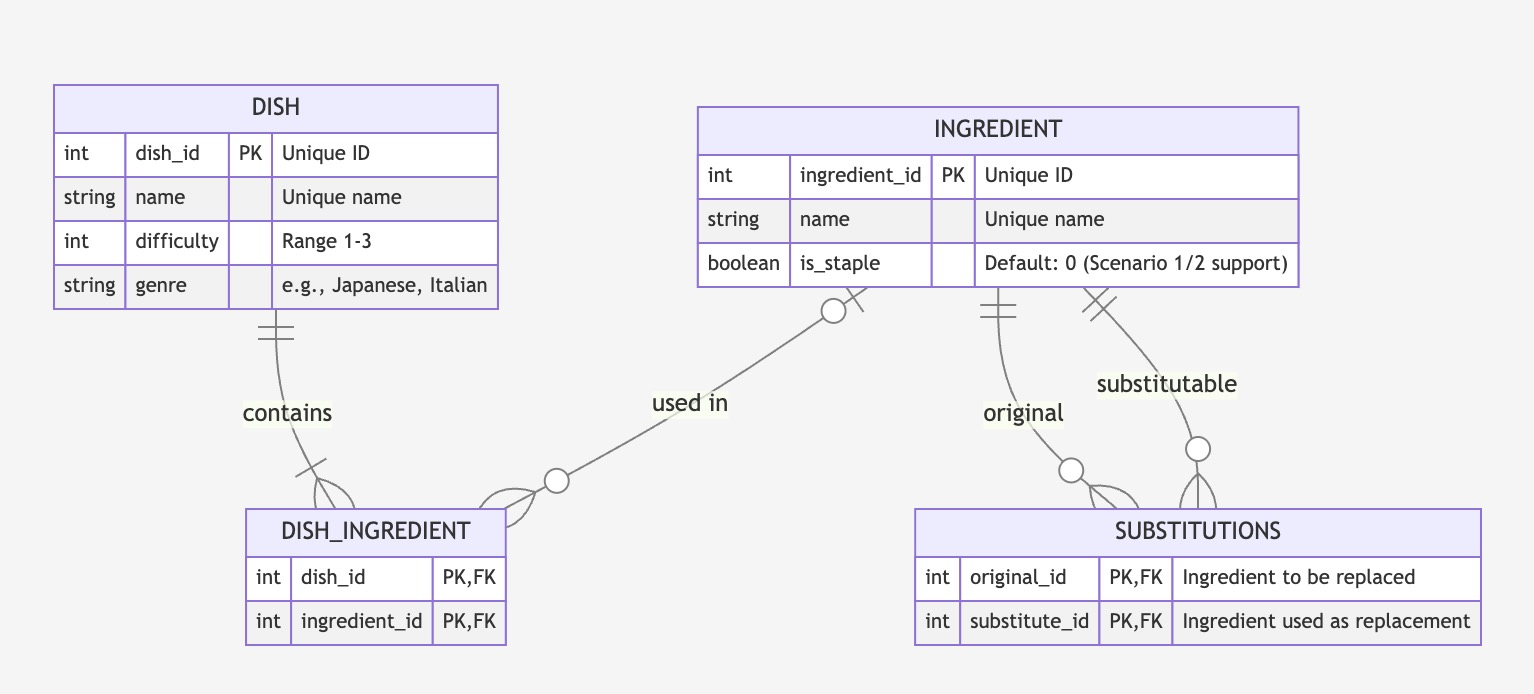

In [ ]:
# 1. Schema Expansion (DDL)
# Adding columns for filtering and logic enhancement
cursor.executescript('''
-- Add Difficulty and Genre to Dish
-- difficulty: 1 (Easy), 2 (Medium), 3 (Hard)
ALTER TABLE Dish ADD COLUMN difficulty INTEGER CHECK (difficulty BETWEEN 1 AND 3);
ALTER TABLE Dish ADD COLUMN genre TEXT;

-- Add is_staple flag to Ingredient
-- If 1, the item is considered a "staple" (always available)
ALTER TABLE Ingredient ADD COLUMN is_staple BOOLEAN DEFAULT 0;

-- Create Substitution Table for Scenario 1
-- Maps one ingredient to another for flexible recipe matching
CREATE TABLE IF NOT EXISTS Substitutions (
    original_id INTEGER,
    substitute_id INTEGER,
    PRIMARY KEY (original_id, substitute_id),
    FOREIGN KEY (original_id) REFERENCES Ingredient(ingredient_id),
    FOREIGN KEY (substitute_id) REFERENCES Ingredient(ingredient_id)
);
''')

# 2. Data Update and Rule Insertion (DML)
# Updating metadata for both Japanese and French dishes
cursor.executescript('''
-- Update Dish attributes for all registered dishes
UPDATE Dish SET difficulty = 2, genre = 'Japanese' WHERE name = 'Nikujaga';
UPDATE Dish SET difficulty = 1, genre = 'Japanese' WHERE name = 'Curry Rice';
UPDATE Dish SET difficulty = 2, genre = 'Italian' WHERE name = 'Meat Sauce Pasta';
UPDATE Dish SET difficulty = 2, genre = 'French' WHERE name = 'Hachis Parmentier';
UPDATE Dish SET difficulty = 2, genre = 'French' WHERE name = 'Gratin';
UPDATE Dish SET difficulty = 1, genre = 'French' WHERE name = 'Galette';
UPDATE Dish SET difficulty = 1, genre = 'French' WHERE name = 'Crepe';
UPDATE Dish SET difficulty = 1, genre = 'Italian' WHERE name = 'Tiramisu';
UPDATE Dish SET difficulty = 1, genre = 'Japanese' WHERE name = 'Oyakodon';

-- Update Ingredient attributes: Defining common staples
-- Staples like Salt, Oil, and Sugar are treated as "pre-available" in fridge queries
UPDATE Ingredient SET is_staple = 1 WHERE name IN ('Salt', 'Oil', 'Sugar', 'Butter', 'Cacao Powder');

-- Insert Substitution Rule: Shallot can replace Onion (Scenario 1)
-- Mapping: original_id (Onion) -> substitute_id (Shallot)
INSERT INTO Substitutions (original_id, substitute_id)
SELECT i1.ingredient_id, i2.ingredient_id
FROM Ingredient i1, Ingredient i2
WHERE (i1.name = 'Onion' AND i2.name = 'Shallot')
   OR (i1.name = 'Buckwheat Flour' AND i2.name = 'Flour')
   OR (i1.name = 'Flour' AND i2.name = 'Buckwheat Flour');
''')
conn.commit()

print("Database extended with Genre, Difficulty, Staples, and Substitutions.")

# Verification
print("\nFinal Extended Dish Table State:")
display(run_query("SELECT * FROM Dish;"))

print("\nSubstitution Rules Defined:")
display(run_query('''
SELECT i1.name AS Original, i2.name AS Substitute
FROM Substitutions s
JOIN Ingredient i1 ON s.original_id = i1.ingredient_id
JOIN Ingredient i2 ON s.substitute_id = i2.ingredient_id;
'''))

Database extended with Genre, Difficulty, Staples, and Substitutions.

Final Extended Dish Table State:


,dish_id,name,difficulty,genre
0,1,Nikujaga,2,Japanese
1,2,Curry Rice,1,Japanese
2,3,Meat Sauce Pasta,2,Italian
3,4,Hachis Parmentier,2,French
4,5,Gratin,2,French
5,6,Galette,1,French
6,7,Crepe,1,French
7,8,Tiramisu,1,Italian
8,9,Oyakodon,1,Japanese



Substitution Rules Defined:


,Original,Substitute
0,Onion,Shallot
1,Buckwheat Flour,Flour
2,Flour,Buckwheat Flour


### 3.1. Scenario 1: Dishes using substitution

* The user wants to make a Crepe, but they are missing Flour. However, they have Buckwheat Flour (in the fridge?).

* $R_d$: Set of required ingredients for dish $d$
* $A$: Set of ingredients directly available in the fridge.
* $\text{Staple}$: Set of staples (Salt, Oil, etc.).
* $S$: Set of "virtual" ingredients covered by substitutes


  $S = \{ i_{orig} \mid \exists i_{sub} \in A, (i_{orig}, i_{sub}) \in \text{Substitutions} \}$.
* Condition: The dish is selected if its requirements are met by the combination of direct ingredients, substitutes, and staples.

$$R_d \subseteq (A \cup \text{Staple} \cup S)$$



---
Used query



* `WITH Available_Ingredients`: a temporary "virtual fridge" that combines Direct Match (Ingredients you actually have) and Substitution Match (Ingredients you don't have but can cover)
* `HAVING COUNT`: It checks if the total number of required ingredients for the Crepe matches the items in this expanded "virtual fridge."

In [ ]:
print("Enter the ingredients currently in your fridge, separated by commas.")
print("Example: Buckwheat Flour, Egg, Milk")
user_input = input("Your ingredients: ")

ingredients_list = [item.strip() for item in user_input.split(',') if item.strip()]

if not ingredients_list:
    fridge_sql_format = "('')"
else:
    fridge_sql_format = str(tuple(ingredients_list)).replace(",)", ")")

q_scenario_1 = f'''
WITH Available_Ingredients AS (
    SELECT ingredient_id
    FROM Ingredient
    WHERE name IN {fridge_sql_format}

    UNION

    SELECT ingredient_id
    FROM Ingredient
    WHERE is_staple = 1

    UNION

    SELECT s.original_id
    FROM Substitutions s
    JOIN Ingredient i ON s.substitute_id = i.ingredient_id
    WHERE i.name IN {fridge_sql_format}
)
SELECT d.name, d.genre
FROM Dish d
JOIN Dish_Ingredient di ON d.dish_id = di.dish_id
WHERE di.ingredient_id IN (SELECT ingredient_id FROM Available_Ingredients)
GROUP BY d.dish_id
HAVING COUNT(di.ingredient_id) = (
    SELECT COUNT(*) FROM Dish_Ingredient WHERE dish_id = d.dish_id
);
'''

print(f"\n--- Search Results for: {', '.join(ingredients_list) if ingredients_list else 'Empty Fridge'} ---")
run_query(q_scenario_1)

### 3.2. Scenario 2: Multi-Criteria Filtering

* Situation: The user wants to cook something specific: a Japanese dish that is easy to make (Difficulty $\le 1$).
* They want to ensure they have all necessary ingredients (Complete Match) before starting.

* $R_d$: Set of required ingredients for dish $d$.
* $A$: Set of available ingredients in the fridge.
* $\text{Staple}$: Set of staples (Salt, Oil, etc.).
* $G$: Target Genre ('Japanese').
* $D$: Max Difficulty level (from 1 to 3).

Condition: The dish is selected if it satisfies
$$R_d \subseteq (A \cup \text{Staple}) \land \text{genre}(d) = G \land \text{difficulty}(d) \le D$$



---
Used query


* `WHERE`: Directly filters the Dish table for genre and difficulty

* `IN`: Performs the "Complete Match"


In [ ]:
user_ingredients = input("Enter ingredients (e.g., Mascarpone, Egg, Coffee, Ladyfingers): ")
user_genre = input("Enter genre (e.g., French, Italian, Japanese): ")
user_max_diff = input("Enter max difficulty (in integer) [1: Easy, 2: Med, 3: Hard]: ")

fridge_items = tuple(item.strip() for item in user_ingredients.split(','))
fridge_placeholder = str(fridge_items).replace(",)", ")")

q_scenario_2_expanded = f'''
SELECT d.name, d.genre, d.difficulty
FROM Dish d
WHERE d.genre = '{user_genre}'
  AND d.difficulty <= {user_max_diff}
  AND d.dish_id IN (
    SELECT di.dish_id
    FROM Dish_Ingredient di
    JOIN Ingredient i ON di.ingredient_id = i.ingredient_id
    WHERE i.name IN {fridge_placeholder} OR i.is_staple = 1
    GROUP BY di.dish_id
    HAVING COUNT(di.ingredient_id) = (
        SELECT COUNT(*) FROM Dish_Ingredient WHERE dish_id = di.dish_id
    )
);
'''

print(f"\n--- Search Criteria: {user_genre} / Difficulty <= {user_max_diff} / Ingredients: {fridge_items} ---")
results = run_query(q_scenario_2_expanded)
display(results)

### 3.3. Scenario 3: Near-Match Search

* Situation: The user wants to find dishes they are "almost" able to cook.They are willing to go to the store, but only if they only need to buy exactly one more item.

* "near-match" search that generates hopping list


* $R_d$: Set of required ingredients for dish $d$.
* $A \cup \text{Staple}$
* $M_d$: The set of missing ingredients for a dish, calculated as the set difference: $M_d = R_d \setminus (A \cup \text{Staple})$.

Condition: A dish is selected if the size (cardinality) of the missing set is exactly 1.
$$|M_d| = |R_d \setminus (A \cup \text{Staple})| = 1$$



---

Used query

* Inner Subquery: `LEFT JOIN` between the recipe requirements and the user's "virtual fridge" (fridge items + staples). It then uses `GROUP BY` and `HAVING` to count how many ingredients returned a `NULL`

* Outer Query: pick out the specific name of the single `NULL` item.


In [ ]:
user_input_limited = input("Enter what you have (e.g., Chicken, Rice, Onion, Egg): ")

fridge_items = tuple(item.strip() for item in user_input_limited.split(','))
fridge_placeholder = str(fridge_items).replace(",)", ")")

q_scenario_3_interactive = f'''
SELECT
    d.name AS Dish_Name,
    i.name AS Item_to_Buy
FROM Dish d
JOIN Dish_Ingredient di ON d.dish_id = di.dish_id
JOIN Ingredient i ON di.ingredient_id = i.ingredient_id
LEFT JOIN (
    SELECT ingredient_id FROM Ingredient
    WHERE name IN {fridge_placeholder} OR is_staple = 1
) AS Owned ON i.ingredient_id = Owned.ingredient_id
WHERE d.dish_id IN (
    SELECT di2.dish_id
    FROM Dish_Ingredient di2
    LEFT JOIN (
        SELECT ingredient_id FROM Ingredient
        WHERE name IN {fridge_placeholder} OR is_staple = 1
    ) AS Owned2 ON di2.ingredient_id = Owned2.ingredient_id
    GROUP BY di2.dish_id
    HAVING SUM(CASE WHEN Owned2.ingredient_id IS NULL THEN 1 ELSE 0 END) = 1
)
AND Owned.ingredient_id IS NULL;
'''

print(f"\nSearching for dishes where you only need 1 more item...")
results = run_query(q_scenario_3_interactive)
display(results)

## Section 4: The 4th Scenario: LLM-Generated Recipes (via Claude API)

* Situation: The user's fridge contains a combination (e.g., Tofu, Miso, Spinach) for which no dish in the database is a complete match, not even under substitutions.

* Instead of returning an empty result, we call the Claude API to invent a new dish and insert it into the database so that future queries can find it.

* $A$: Set of ingredients in the fridge.
* $\text{Dish}_{\text{db}}$, $\text{Ing}_{\text{db}}$: Existing Dish and Ingredient rows.
* $r = (n, G, D, I, T)$: Recipe returned by the LLM, where $I$ is its ingredient list.

Condition: After the call, the database state is updated so that
$$\text{Dish}_{\text{db}} \gets \text{Dish}_{\text{db}} \cup \{n\}, \quad \text{Ing}_{\text{db}} \gets \text{Ing}_{\text{db}} \cup I, \quad I \subseteq \text{Ing}_{\text{db}}$$

with the three writes committed atomically.



* `ALTER TABLE`: Extends `Dish` with `instructions` and `source` so an LLM recipe can be stored in full.

* `INSERT OR IGNORE`: Uses the `UNIQUE` constraint on `Ingredient.name` to silently skip ingredients that already exist, preventing duplicates.

* Transaction (`commit` / `rollback`): The three writes (new `Ingredient` rows, new `Dish` row, new `Dish_Ingredient` links) succeed together or are all undone, preserving referential integrity.

### 4.1. Preliminary

In [ ]:
cursor.executescript('''
ALTER TABLE Dish ADD COLUMN instructions TEXT;
ALTER TABLE Dish ADD COLUMN source TEXT DEFAULT 'seed';
''')

# Mark the rows that already existed as 'seed' so the new 'source' column is never NULL
cursor.execute("UPDATE Dish SET source = 'seed' WHERE source IS NULL;")
conn.commit()

print("Database extended with `instructions` and `source` columns on Dish.")
display(run_query("SELECT dish_id, name, genre, difficulty, source FROM Dish;"))


Database extended with `instructions` and `source` columns on Dish.


,dish_id,name,genre,difficulty,source
0,1,Nikujaga,Japanese,2,seed
1,2,Curry Rice,Japanese,1,seed
2,3,Meat Sauce Pasta,Italian,2,seed
3,4,Hachis Parmentier,French,2,seed
4,5,Gratin,French,2,seed
5,6,Galette,French,1,seed
6,7,Crepe,French,1,seed
7,8,Tiramisu,Italian,1,seed
8,9,Oyakodon,Japanese,1,seed


In [ ]:
import os
import json
from anthropic import Anthropic

#Load the API key
try:
    from google.colab import userdata
    os.environ['ANTHROPIC_API_KEY'] = userdata.get('ANTHROPIC_API_KEY')
except ImportError:
    # Local/Jupyter: we assume the ANTHROPIC_API_KEY env variable is already set
    pass

#Instantiate the client (picks up ANTHROPIC_API_KEY from the environment)
client = Anthropic()

CLAUDE_MODEL = "claude-sonnet-4-6"

print(f"Anthropic client ready. Using model: {CLAUDE_MODEL}")


Anthropic client ready. Using model: claude-sonnet-4-6


In [ ]:
# Scenario 4 helpers


def generate_recipe_with_claude(fridge_ingredients):
    """Ask Claude to invent ONE new dish from the given fridge contents.
    Returns a dict with keys: name, genre, difficulty, ingredients, instructions."""

    known_ingredients = run_query("SELECT name FROM Ingredient;")['name'].tolist()
    known_dishes      = run_query("SELECT name FROM Dish;"      )['name'].tolist()

    prompt = f"""You are a professional chef recommending a well-known, real-world dish.

The user's fridge currently contains: {', '.join(fridge_ingredients)}.
Assume common staples (Salt, Oil, Sugar, Butter) are always available.

Suggest ONE authentic dish that is traditionally made with the fridge ingredients listed above.
The dish must be a real recipe that exists in the culinary tradition of its genre,
not an invented or fusion creation.
The dish name MUST NOT appear in this list of already-known dishes:
{', '.join(known_dishes)}

Whenever an ingredient you want matches one from the known list below, REUSE the exact same spelling:
{', '.join(known_ingredients)}

Respond with a single JSON object, and nothing else, matching exactly this schema:
{{
  "name": "<original dish name>",
  "genre": "<Japanese | French | Italian | Fusion | Other>",
  "difficulty": <integer 1 (easy), 2 (medium), or 3 (hard)>,
  "ingredients": ["<ingredient 1>", "<ingredient 2>", ...],
  "instructions": "<step-by-step cooking instructions, 3 to 8 short steps>"
}}"""

    response = client.messages.create(
        model=CLAUDE_MODEL,
        max_tokens=1024,
        messages=[{"role": "user", "content": prompt}],
    )

    # The API returns content as a list of blocks: the first text block is our answer
    text = response.content[0].text.strip()

    # Strip Markdown code fences if Claude wrapped the JSON in ```json ... ```
    if text.startswith("```"):
        text = text.strip("`")
        if text.lower().startswith("json"):
            text = text[4:]
        text = text.strip()

    return json.loads(text)


def register_recipe_in_db(recipe):
    """Insert a Claude-generated recipe into the database atomically.
    On any integrity error the whole insertion is rolled back."""

    try:
        # 1. Any ingredient name the LLM returned that is NOT yet in Ingredient must be added.
        #    INSERT OR IGNORE relies on the UNIQUE constraint on Ingredient.name to deduplicate.
        for ing_name in recipe['ingredients']:
            cursor.execute(
                "INSERT OR IGNORE INTO Ingredient (name) VALUES (?);",
                (ing_name,)
            )

        # 2. New Dish row — fails (and triggers rollback) if the name already exists.
        cursor.execute(
            '''INSERT INTO Dish (name, difficulty, genre, instructions, source)
               VALUES (?, ?, ?, ?, 'llm');''',
            (recipe['name'], int(recipe['difficulty']), recipe['genre'], recipe['instructions'])
        )
        new_dish_id = cursor.lastrowid

        # 3. N:M links — we look up each ingredient_id by name so the FK to Ingredient is guaranteed valid (referential integrity).
        for ing_name in recipe['ingredients']:
            cursor.execute(
                '''INSERT INTO Dish_Ingredient (dish_id, ingredient_id)
                   SELECT ?, ingredient_id FROM Ingredient WHERE name = ?;''',
                (new_dish_id, ing_name)
            )

        conn.commit()
        return new_dish_id

    except sqlite3.IntegrityError as e:
        # Atomicity: undo partial writes if anything above failed
        conn.rollback()
        raise RuntimeError(f"Could not register recipe: {e}")


print("Helper functions `generate_recipe_with_claude` and `register_recipe_in_db` ready.")


Helper functions `generate_recipe_with_claude` and `register_recipe_in_db` ready.


### 4.2. Execution of Scenario 4

In [ ]:
# Scenario 4 — Interactive demo
# Ask Claude to invent a dish from whatever the user types, show it, then persist it.

# 1. Get input from the user (comma-separated), same style as Scenarios 1-3
user_input_llm = input("Enter the ingredients in your fridge (e.g., Tofu, Miso, Spinach, Seaweed): ")
fridge_items_llm = [item.strip() for item in user_input_llm.split(',') if item.strip()]

# 2. Call the Claude API — this is where the new recipe is invented
print(f"\nCalling Claude API with: {fridge_items_llm}")
new_recipe = generate_recipe_with_claude(fridge_items_llm)

# 3. Show the proposed recipe BEFORE writing to the DB, so the demo audience can read it
print("\n--- Proposed New Recipe ---")
print(f"Name        : {new_recipe['name']}")
print(f"Genre       : {new_recipe['genre']}")
print(f"Difficulty  : {new_recipe['difficulty']}")
print(f"Ingredients : {', '.join(new_recipe['ingredients'])}")
print(f"\nInstructions:\n{new_recipe['instructions']}")

# 4. Persist to the database (transaction + referential integrity)
new_dish_id = register_recipe_in_db(new_recipe)
print(f"\nRecipe registered with dish_id = {new_dish_id}.")

# 5. Verification — prove the row is really in the DB by SELECTing it back
print("\n--- Verification: the new dish is now in the database ---")
display(run_query("SELECT dish_id, name, genre, difficulty, source FROM Dish WHERE dish_id = ?;",
                  params=(new_dish_id,)))

print("--- Ingredients linked to the new dish (via Dish_Ingredient join) ---")
display(run_query('''
    SELECT i.name AS Ingredient
    FROM Dish_Ingredient di
    JOIN Ingredient i ON di.ingredient_id = i.ingredient_id
    WHERE di.dish_id = ?;
''', params=(new_dish_id,)))

# 6. Closing the loop: the new dish is now reachable by the Section-3 queries.
#    Running a complete-match check confirms that if the user keeps the same fridge,
#    the dish they just invented will now be suggested by Scenario 2-style queries.
fridge_placeholder = str(tuple(fridge_items_llm)).replace(",)", ")")
print("--- Re-running a complete-match query on the same fridge ---")
display(run_query(f'''
    SELECT d.name, d.genre, d.difficulty, d.source
    FROM Dish d
    JOIN Dish_Ingredient di ON d.dish_id = di.dish_id
    JOIN Ingredient i       ON di.ingredient_id = i.ingredient_id
    WHERE i.name IN {fridge_placeholder} OR i.is_staple = 1
    GROUP BY d.dish_id
    HAVING COUNT(di.ingredient_id) = (
        SELECT COUNT(*) FROM Dish_Ingredient WHERE dish_id = d.dish_id
    );
'''))


Enter the ingredients in your fridge (e.g., Tofu, Miso, Spinach, Seaweed): Tofu, Miso, Spinach, Seaweed

Calling Claude API with: ['Tofu', 'Miso', 'Spinach', 'Seaweed']

--- Proposed New Recipe ---
Name        : Miso Soup with Tofu and Wakame
Genre       : Japanese
Difficulty  : 1
Ingredients : Miso, Tofu, Seaweed, Salt

Instructions:
1. Bring 600ml of water to a gentle simmer in a pot. 2. Add a small piece of dried Seaweed (wakame) and let it rehydrate for 2-3 minutes. 3. Cut Tofu into small cubes and gently add to the pot. 4. Reduce heat to low so the water is no longer boiling. 5. Dissolve 2-3 tablespoons of Miso into a ladle with a small amount of the hot broth, then stir back into the pot. 6. Taste and adjust seasoning with a pinch of Salt if needed. 7. Serve immediately in bowls, being careful not to boil the soup after adding the miso.

Recipe registered with dish_id = 12.

--- Verification: the new dish is now in the database ---


,dish_id,name,genre,difficulty,source
0,12,Miso Soup with Tofu and Wakame,Japanese,1,llm


--- Ingredients linked to the new dish (via Dish_Ingredient join) ---


,Ingredient
0,Salt
1,Tofu
2,Miso
3,Seaweed


--- Re-running a complete-match query on the same fridge ---


,name,genre,difficulty,source
0,Miso Soup with Tofu and Wakame,Japanese,1,llm


In [ ]:
print("Database state after recipe generation")

# [Dish] — the new row carries source='llm' and sits at the end by dish_id
print("\n[Dish]")
display(run_query("SELECT dish_id, name, genre, difficulty, source FROM Dish ORDER BY dish_id;"))

# [Ingredient] — any ingredient name that did not exist yet is appended with a new ingredient_id
print("\n[Ingredient]")
display(run_query("SELECT ingredient_id, name, is_staple FROM Ingredient ORDER BY ingredient_id;"))

# [Dish_Ingredient] — N:M links for every dish; rows for the new dish appear at the bottom
print("\n[Dish_Ingredient]")
display(run_query('''
    SELECT di.dish_id, d.name AS dish_name,
           di.ingredient_id, i.name AS ingredient_name
    FROM Dish_Ingredient di
    JOIN Dish d       ON di.dish_id = d.dish_id
    JOIN Ingredient i ON di.ingredient_id = i.ingredient_id
    ORDER BY di.dish_id, di.ingredient_id;
'''))


Database state after recipe generation

[Dish]


,dish_id,name,genre,difficulty,source
0,1,Nikujaga,Japanese,2,seed
1,2,Curry Rice,Japanese,1,seed
2,3,Meat Sauce Pasta,Italian,2,seed
3,4,Hachis Parmentier,French,2,seed
4,5,Gratin,French,2,seed
5,6,Galette,French,1,seed
6,7,Crepe,French,1,seed
7,8,Tiramisu,Italian,1,seed
8,9,Oyakodon,Japanese,1,seed
9,10,Miso Caramel Tofu Bowl with Seaweed Spinach,Japanese,2,llm



[Ingredient]


,ingredient_id,name,is_staple
0,1,Carrot,0
1,2,Onion,0
2,3,Potato,0
3,4,Pork,0
4,5,Curry Roux,0
5,6,Celery,0
6,7,Minced Beef,0
7,8,Tomato Sauce,0
8,9,Salt,1
9,10,Oil,1



[Dish_Ingredient]


,dish_id,dish_name,ingredient_id,ingredient_name
0,1,Nikujaga,1,Carrot
1,1,Nikujaga,2,Onion
2,1,Nikujaga,3,Potato
3,1,Nikujaga,4,Pork
4,2,Curry Rice,1,Carrot
...,...,...,...,...
56,11,Chocolate Pain Perdu,36,Bread
57,12,Miso Soup with Tofu and Wakame,9,Salt
58,12,Miso Soup with Tofu and Wakame,27,Tofu
59,12,Miso Soup with Tofu and Wakame,28,Miso


# Possible Extensions


There still exists problems:
* Concurrent access
  * Force users to create accounts and identifies if there are two or logged-in from different devices and two or more queries with the same ingredient in a certain time (e.g. within 30 minutes)
  * Ingredients in `Staple` can be shared.



* Ambiguous Recipe
  * What is tomato pasta? (a class of noodles, sauce/fresh/dry/whole tomatoes, cheese,)
  * `type` as a ingredient might be implemented;
    * pairwise sustitutable within a class of cheese?
    * Another problem: parmigiano and pecorino? parmigiano and mascarpone? smaller class of cheese


